# 01 — Coordinate systems

Getting a simulated electric field onto a real antenna is, more than anything
else, a coordinate problem. Air showers are computed in shower coordinates;
antennas sit at geodetic positions on curved, uneven terrain; the radio
emission is driven by the local geomagnetic field.

This notebook is the long form of the
[coordinates page](https://grand-mother.github.io/grand-docs/coordinates.html):
the frames, the conversions between them, the two conventions that most often
catch people out, and a worked layout at the GRANDProto300 site.

**Prerequisites**: a working `grand-dev` environment.

```bash
conda env create -f env/conda/grand-dev.yml --solver=libmamba
conda activate grand-dev
source env/setup.sh
jupyter lab notebooks/
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from grand import Geodetic, ECEF, LTP, GRANDCS
from grand.geo.coordinates import Reference, geoid_undulation

# The GRANDProto300 site at Dunhuang, China.
SITE = Geodetic(latitude=40.98, longitude=93.95, height=1200.0)
print("site:", np.asarray(SITE).ravel())

site: [  40.98   93.95 1200.  ]


## 1. The four frames

| Frame | What it is |
|---|---|
| `Geodetic` | latitude, longitude, height — degrees and metres |
| `ECEF` | Earth-Centred Earth-Fixed Cartesian; the common pivot |
| `LTP` | a local tangent plane at a chosen origin and orientation |
| `GRANDCS` | the array frame: an `LTP` with GRAND's conventions |

Every conversion between a local frame and geodetic passes through `ECEF`.
There is no direct path, and that is deliberate: one pivot means one place for
the ellipsoid constants to live.

In [2]:
ecef = ECEF(SITE)
print("ECEF (m):   ", np.round(np.asarray(ecef).ravel(), 1))
print("round trip: ", np.round(np.asarray(Geodetic(ecef)).ravel(), 6))

ECEF (m):    [-332233.2 4811491.3 4161528.6]
round trip:  [  40.98   93.95 1200.  ]


## 2. The trap: `x` is not `x`

`GRANDCS` and `LTP` take the same three numbers and mean different things by
them. `LTP` with `orientation='ENU'` is east-north-up, so its `x` runs **east**.
`GRANDCS` follows the array convention, and its `x` runs **north**.

In [3]:
a = ECEF(GRANDCS(x=1000.0, y=0.0, z=0.0, location=SITE))
b = ECEF(LTP(x=1000.0, y=0.0, z=0.0, location=SITE,
             orientation='ENU', magnetic=False))

separation = np.linalg.norm(np.asarray(a).ravel() - np.asarray(b).ravel())
print("same three numbers, different frame: %.1f m apart" % separation)

same three numbers, different frame: 1410.6 m apart


No exception, no warning, and both answers are perfectly valid — they answer
different questions. A detector position confused this way lands outside the
array footprint; a shower axis confused this way points at the wrong patch of
sky.

The habit that prevents it is to name the frame in the variable rather than
relying on the constructor alone: `du_grandcs`, `axis_enu`.

In [4]:
for name, orientation in [('ENU', 'ENU'), ('NWU (GRAND)', 'NWU')]:
    step = Geodetic(LTP(x=0.0, y=1000.0, z=0.0, location=SITE,
                        orientation=orientation, magnetic=False))
    lat, lon, _ = np.asarray(step).ravel()
    moved = 'north' if lat > 40.98 else ('west' if lon < 93.95 else 'east')
    print("1 km along y in %-12s -> %s" % (name, moved))

1 km along y in ENU          -> north
1 km along y in NWU (GRAND)  -> west


## 3. Magnetic versus geographic north

`magnetic=True` measures the horizontal axes from magnetic north. The
declination at Dunhuang is a few degrees, which over a 10 km array is hundreds
of metres — a choice to make deliberately, not a default to inherit.

> **The date matters, and the shipped model has expired.** `data/geomagnet/IGRF13.COF`
> is IGRF-13, defined to 2025, so any `obstime` from 2025-01-01 onward raises
> `LibraryError: missing data`. The example below uses 2024 for that reason.
> See the known-issues page.

In [5]:
geo = ECEF(LTP(x=1000.0, y=0.0, z=0.0, location=SITE,
               orientation='ENU', magnetic=False))
mag = ECEF(LTP(x=1000.0, y=0.0, z=0.0, location=SITE,
               orientation='ENU', magnetic=True, obstime='2024-06-01'))

print("geographic vs magnetic north, 1 km out: %.1f m apart"
      % np.linalg.norm(np.asarray(geo).ravel() - np.asarray(mag).ravel()))

geographic vs magnetic north, 1 km out: 0.6 m apart


## 4. Heights need a reference

A height is meaningless without saying what it is measured from. The ellipsoid
is a smooth mathematical figure; the geoid is mean sea level. They differ by up
to about 100 m worldwide.

In [6]:
undulation = geoid_undulation(latitude=40.98, longitude=93.95)
print("geoid - ellipsoid at Dunhuang: %.2f m" % undulation)
print("1200 m above the ellipsoid is %.2f m above sea level" % (1200.0 - undulation))
print("available references:", list(Reference))

geoid - ellipsoid at Dunhuang: -7.75 m
1200 m above the ellipsoid is 1207.75 m above sea level
available references: [<Reference.ELLIPSOID: 1>, <Reference.GEOID: 2>]


## 5. A detector layout, in two frames

A small hexagonal array in `GRANDCS`, then the same units as latitude and
longitude. This is the round trip every simulation performs, drawn.

array spans 0.0360 deg of latitude, 0.0475 deg of longitude


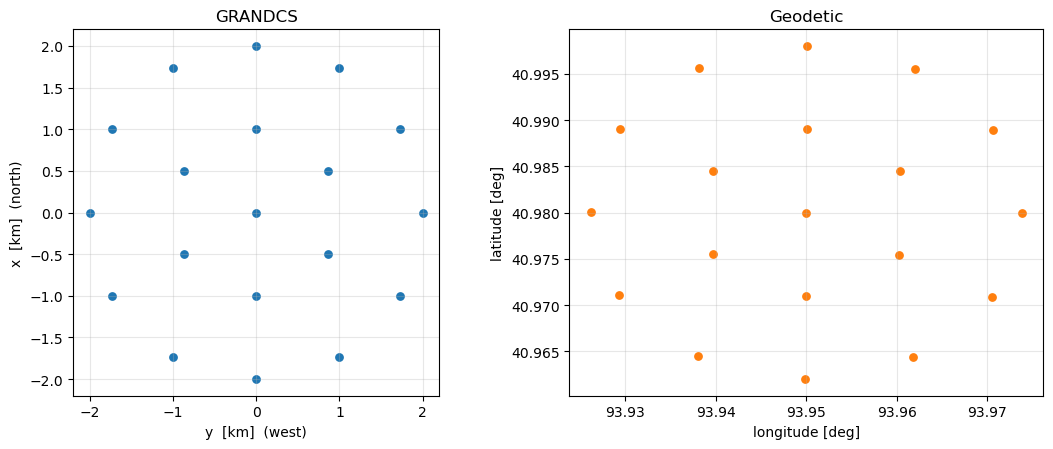

In [7]:
# a hexagonal layout, 1 km spacing, in the array frame
spacing = 1000.0
positions = [(0.0, 0.0)]
for ring in (1, 2):
    for k in range(6 * ring):
        angle = 2 * np.pi * k / (6 * ring)
        positions.append((ring * spacing * np.cos(angle),
                          ring * spacing * np.sin(angle)))
positions = np.array(positions)

geodetic = np.array([
    np.asarray(Geodetic(GRANDCS(x=float(x), y=float(y), z=0.0, location=SITE))).ravel()
    for x, y in positions])

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4.6))
left.scatter(positions[:, 1] / 1000, positions[:, 0] / 1000, s=28)
left.set_xlabel('y  [km]  (west)'); left.set_ylabel('x  [km]  (north)')
left.set_title('GRANDCS'); left.set_aspect('equal'); left.grid(alpha=.3)

right.scatter(geodetic[:, 1], geodetic[:, 0], s=28, color='C1')
right.set_xlabel('longitude [deg]'); right.set_ylabel('latitude [deg]')
right.set_title('Geodetic'); right.grid(alpha=.3)
fig.tight_layout()

print("array spans %.4f deg of latitude, %.4f deg of longitude"
      % (np.ptp(geodetic[:, 0]), np.ptp(geodetic[:, 1])))

Note the aspect: a degree of longitude is shorter than a degree of latitude at
40°N, so the array that is circular in `GRANDCS` is elliptical when plotted
against raw degrees. That is not a bug in the conversion — it is why one works
in a local frame.

## 6. A shower axis in both frames

A shower arriving at 85° zenith from the north, expressed as a direction in the
array frame and then as the geodetic points along its path.

In [8]:
zenith, azimuth = np.radians(85.0), np.radians(0.0)
direction = np.array([np.sin(zenith) * np.cos(azimuth),
                      np.sin(zenith) * np.sin(azimuth),
                      np.cos(zenith)])
print("unit direction in GRANDCS (x north, y west, z up):", np.round(direction, 4))

along = np.array([
    np.asarray(Geodetic(GRANDCS(x=float(d * direction[0]),
                                y=float(d * direction[1]),
                                z=float(d * direction[2]), location=SITE))).ravel()
    for d in np.linspace(0, 20000, 6)])

for d, (lat, lon, h) in zip(np.linspace(0, 20, 6), along):
    print("  %5.1f km along the axis -> lat %.4f, lon %.4f, height %7.1f m"
          % (d, lat, lon, h))

unit direction in GRANDCS (x north, y west, z up): [0.9962 0.     0.0872]
    0.0 km along the axis -> lat 40.9800, lon 93.9500, height  1200.0 m
    4.0 km along the axis -> lat 41.0159, lon 93.9502, height  1549.8 m
    8.0 km along the axis -> lat 41.0517, lon 93.9505, height  1902.1 m
   12.0 km along the axis -> lat 41.0876, lon 93.9507, height  2256.8 m
   16.0 km along the axis -> lat 41.1235, lon 93.9510, height  2614.1 m
   20.0 km along the axis -> lat 41.1593, lon 93.9512, height  2973.8 m


The height climbs as the axis rises, and the latitude increases because the
shower comes from the north — both consistent with `GRANDCS` `x` running north.

## Where next

- [02 — Reading and writing GRAND data](02_data_model.ipynb)
- [03 — The antenna response](03_antenna_response.ipynb)
- The [coordinates page](https://grand-mother.github.io/grand-docs/coordinates.html)